# Etapa 2 — Análise Exploratória e Limpeza

**ImunizaData** — cobertura vacinal por município (SUS).

Este notebook lê o dataset já limpo e cruzado (`refined/cobertura_vacinal`,
gerado por `src/cleaning/build_coverage.py`) e faz a análise exploratória:
distribuição da métrica de cobertura, outliers, e o cruzamento com
população.

> Antes de rodar este notebook: `docker-compose up -d`, depois
> `python -m src.ingestion.download_ibge --ano 2024`,
> `python -m src.ingestion.download_pni --ano 2025`,
> `python -m src.cleaning.clean_ibge --ano 2024`,
> `python -m src.cleaning.clean_pni --ano 2025`,
> `python -m src.cleaning.build_coverage --ano 2025`
> (ajuste os anos conforme o escopo definido para o projeto).

In [1]:
import io
import os
import sys

sys.path.insert(0, os.path.abspath(".."))

import boto3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from botocore.client import Config

from src.config import MINIO_ACCESS_KEY, MINIO_ENDPOINT, MINIO_SECRET_KEY

sns.set_theme(style="whitegrid")

ANO = 2025
BUCKET_REFINED = os.getenv("MINIO_REFINED_BUCKET", "refined")

s3 = boto3.client(
    "s3",
    endpoint_url=MINIO_ENDPOINT,
    aws_access_key_id=MINIO_ACCESS_KEY,
    aws_secret_access_key=MINIO_SECRET_KEY,
    config=Config(signature_version="s3v4"),
)

key = f"cobertura_vacinal/ano={ANO}/cobertura_municipios.parquet"
obj = s3.get_object(Bucket=BUCKET_REFINED, Key=key)
df = pd.read_parquet(io.BytesIO(obj["Body"].read()))
df.shape

(5571, 8)

## 1. Visão geral

In [2]:
df.head()

,codigo_municipio,municipio,ano,populacao,unidade_medida,nivel_territorial,doses_aplicadas,cobertura_doses_por_100_habitantes
0,1100015,Alta Floresta D'Oeste - RO,9324,22787,Pessoas,Município,20283,89.01
1,1100023,Ariquemes - RO,9324,109170,Pessoas,Município,86774,79.49
2,1100031,Cabixi - RO,9324,5664,Pessoas,Município,3757,66.33
3,1100049,Cacoal - RO,9324,98280,Pessoas,Município,74367,75.67
4,1100056,Cerejeiras - RO,9324,16966,Pessoas,Município,16918,99.72


In [3]:
df.info()
print("\nValores ausentes por coluna:")
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 8 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   codigo_municipio                    5571 non-null   str    
 1   municipio                           5571 non-null   str    
 2   ano                                 5571 non-null   str    
 3   populacao                           5571 non-null   int64  
 4   unidade_medida                      5571 non-null   str    
 5   nivel_territorial                   5571 non-null   str    
 6   doses_aplicadas                     5571 non-null   int64  
 7   cobertura_doses_por_100_habitantes  5571 non-null   float64
dtypes: float64(1), int64(2), str(5)
memory usage: 593.8 KB

Valores ausentes por coluna:
codigo_municipio                      0
municipio                             0
ano                                   0
populacao                             0
unida

In [4]:
df["cobertura_doses_por_100_habitantes"].describe()

count    5571.000000
mean       84.257300
std        26.444305
min        16.590000
25%        73.240000
50%        82.310000
75%        92.765000
max      1606.410000
Name: cobertura_doses_por_100_habitantes, dtype: float64

## 2. Distribuição da cobertura vacinal

Lembrete: a métrica é "doses aplicadas por 100 habitantes" (proxy de
intensidade de vacinação), não "% de pessoas vacinadas" — ver
`docs/decisoes_limpeza.md`.

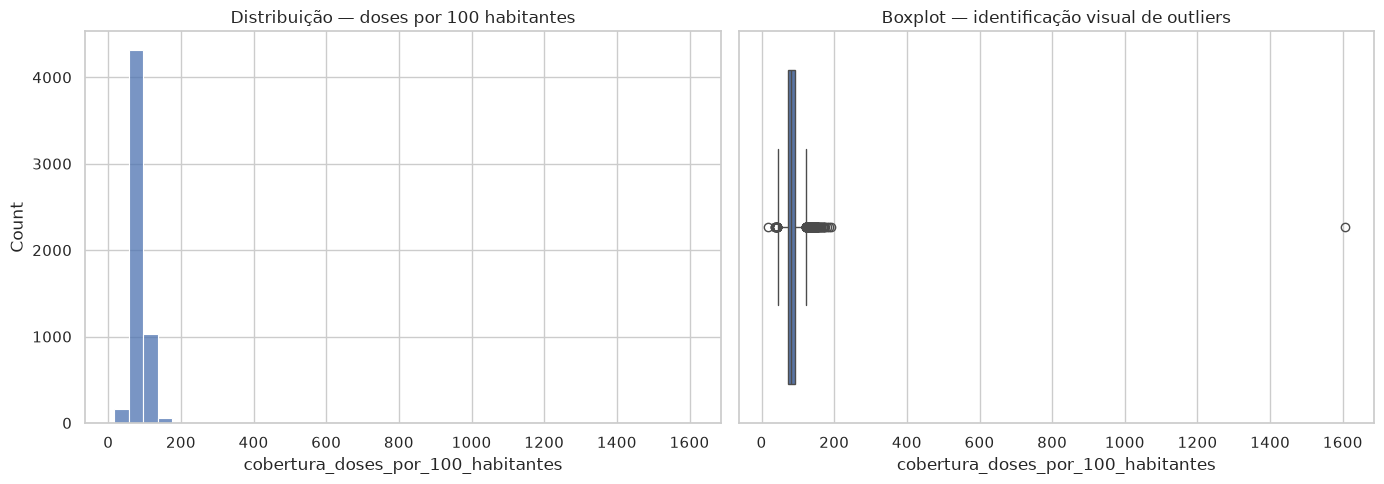

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["cobertura_doses_por_100_habitantes"], bins=40, ax=axes[0])
axes[0].set_title("Distribuição — doses por 100 habitantes")

sns.boxplot(x=df["cobertura_doses_por_100_habitantes"], ax=axes[1])
axes[1].set_title("Boxplot — identificação visual de outliers")

plt.tight_layout()
plt.savefig("../reports/distribuicao_cobertura.png", dpi=150)
plt.show()

## 3. Municípios extremos

Menor e maior cobertura — os de maior cobertura merecem checagem: podem ser
polos regionais de vacinação (atendem população de municípios vizinhos), o
que infla o numerador sem refletir a população local (ver coluna
`outlier_iqr` no dataset `trusted` de doses, por mês).

In [6]:
colunas_exibir = [
    "codigo_municipio",
    "municipio",
    "populacao",
    "doses_aplicadas",
    "cobertura_doses_por_100_habitantes",
]

print("10 municípios com MENOR cobertura:")
display(df.nsmallest(10, "cobertura_doses_por_100_habitantes")[colunas_exibir])

print("\n10 municípios com MAIOR cobertura:")
display(df.nlargest(10, "cobertura_doses_por_100_habitantes")[colunas_exibir])

10 municípios com MENOR cobertura:


,codigo_municipio,municipio,populacao,doses_aplicadas,cobertura_doses_por_100_habitantes
5199,5101837,Boa Esperança do Norte - MT,5877,975,16.59
3576,3527405,Lucélia - SP,20378,7287,35.76
3566,3526506,Lavínia - SP,9940,3588,36.10
4817,4310553,Itacurubi - RS,3038,1159,38.15
3849,3552304,Sud Mennucci - SP,7464,3022,40.49
2424,3116407,Claraval - MG,4786,1968,41.12
4973,4317004,Santana da Boa Vista - RS,7128,2945,41.32
3253,3305307,São Sebastião do Alto - RJ,7993,3375,42.22
1123,2404408,Grossos - RN,10281,4398,42.78
4989,4318101,São Francisco de Assis - RS,17934,7696,42.91



10 municípios com MAIOR cobertura:


,codigo_municipio,municipio,populacao,doses_aplicadas,cobertura_doses_por_100_habitantes
146,1400456,Pacaraima - RR,23112,371274,1606.41
79,1300201,Atalaia do Norte - AM,15889,30200,190.07
5203,5102603,Campinápolis - MT,15808,29507,186.66
5255,5106174,Nova Nazaré - MT,4575,8207,179.39
5141,5004403,Inocência - MS,8764,15318,174.78
123,1303601,Santa Isabel do Rio Negro - AM,13947,23831,170.87
53,1200054,Assis Brasil - AC,8648,14756,170.63
75,1300060,Amaturá - AM,11533,19478,168.89
81,1300409,Barcelos - AM,18210,30652,168.33
4872,4312625,Muliterno - RS,1754,2892,164.88


## 4. Cobertura vs. população

Municípios pequenos tendem a ter métricas mais voláteis (poucas doses já
mudam muito o percentual) — útil para decidir se vale a pena um corte
mínimo de população antes da Etapa 3 (clusterização/classificação).

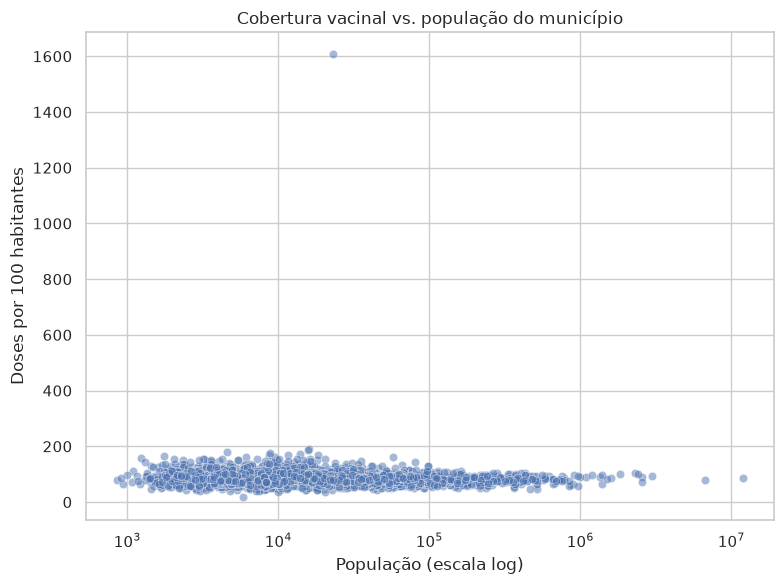

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="populacao",
    y="cobertura_doses_por_100_habitantes",
    alpha=0.5,
    ax=ax,
)
ax.set_xscale("log")
ax.set_xlabel("População (escala log)")
ax.set_ylabel("Doses por 100 habitantes")
ax.set_title("Cobertura vacinal vs. população do município")
plt.tight_layout()
plt.savefig("../reports/cobertura_vs_populacao.png", dpi=150)
plt.show()

## 5. Próximos passos (pendente de dados adicionais)

Análise de correlação com variáveis socioeconômicas (renda, IDH) — citada
no objetivo do projeto — depende de coletar essas variáveis do IBGE/SIDRA,
o que ainda não foi feito na Etapa 1 (só população foi coletada). Ver
"Pendências conhecidas" em `docs/decisoes_limpeza.md`.